In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
df = pd.read_csv("../data/ethiopia.csv")
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58


In [8]:
df["Country"] = "Ethiopia"

In [9]:
df["date"] = pd.to_datetime(
    df["YEAR"] * 1000 + df["DOY"],
    format="%Y%j"
)

In [10]:
df = df.replace(-999, np.nan)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df = df.drop_duplicates()

In [13]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,date
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN


In [14]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100
missing_percent

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
date           0.0
dtype: float64

In [19]:
!pip install scipy

  Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl.metadata (60 kB)
Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl (37.3 MB)


In [15]:
missing_percent[missing_percent > 5]

Series([], dtype: float64)

In [20]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = df[cols].apply(zscore)

outliers = (z_scores.abs() > 3)
outliers_count = outliers.sum()

outliers_count

T2M             3
T2M_MAX         0
T2M_MIN        18
PRECTOTCORR    95
RH2M           13
WS2M            3
WS2M_MAX        5
dtype: int64

In [21]:
for col in cols:
    upper = df[col].mean() + 3 * df[col].std()
    lower = df[col].mean() - 3 * df[col].std()
    df[col] = np.clip(df[col], lower, upper)

In [23]:
df = df.ffill()

In [24]:
df = df.dropna()

In [26]:
df.to_csv("../data/ethiopia_clean.csv", index=False)

In [29]:
df["date"] = pd.to_datetime(df["date"])

In [30]:
df["Month"] = df["date"].dt.month

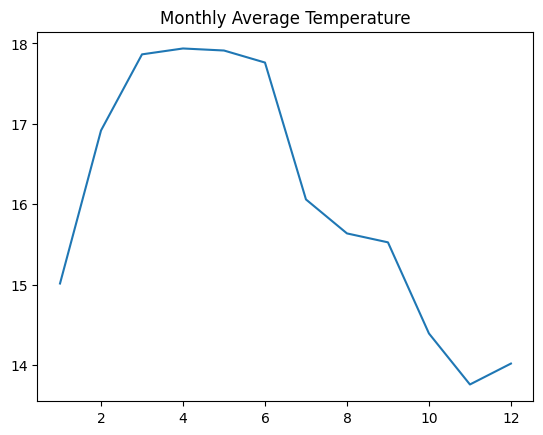

In [31]:
monthly_temp = df.groupby("Month")["T2M"].mean()

plt.plot(monthly_temp.index, monthly_temp.values)
plt.title("Monthly Average Temperature")
plt.show()

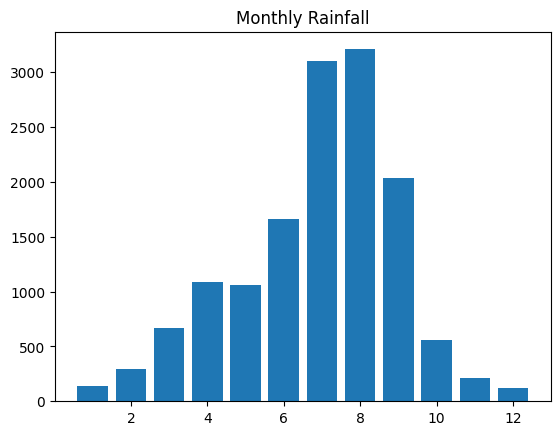

In [32]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

plt.bar(monthly_rain.index, monthly_rain.values)
plt.title("Monthly Rainfall")
plt.show()

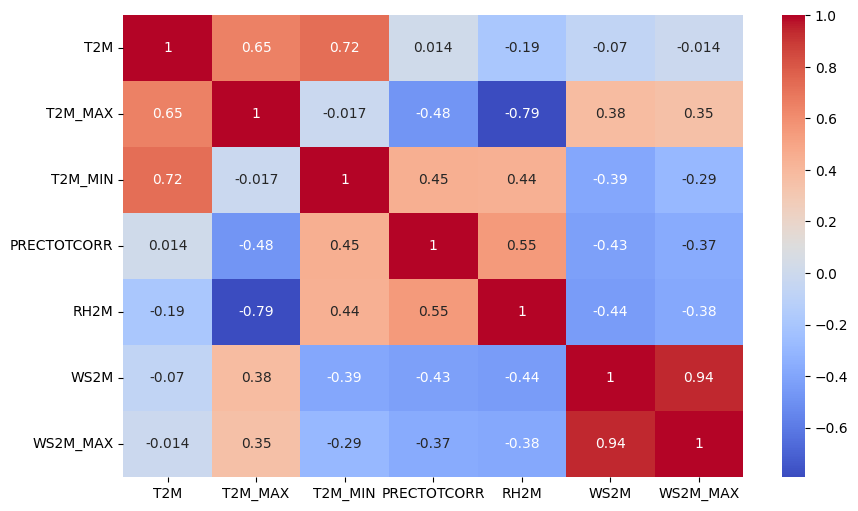

In [33]:
plt.figure(figsize=(10,6))
sns.heatmap(df[cols].corr(), annot=True, cmap="coolwarm")
plt.show()

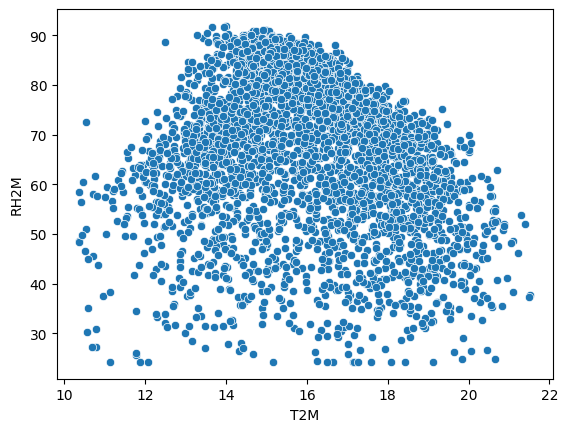

In [34]:
sns.scatterplot(data=df, x="T2M", y="RH2M")
plt.show()

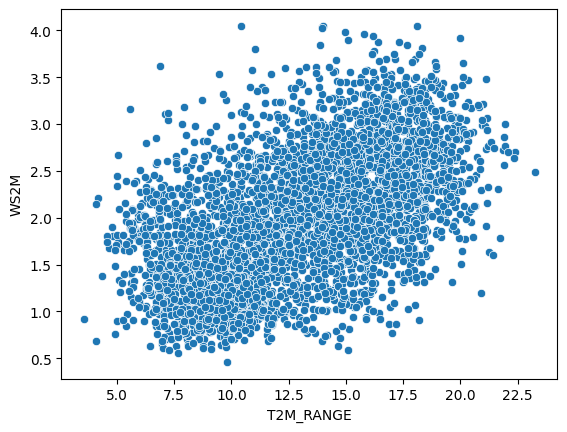

In [35]:
df["T2M_RANGE"] = df["T2M_MAX"] - df["T2M_MIN"]

sns.scatterplot(data=df, x="T2M_RANGE", y="WS2M")
plt.show()

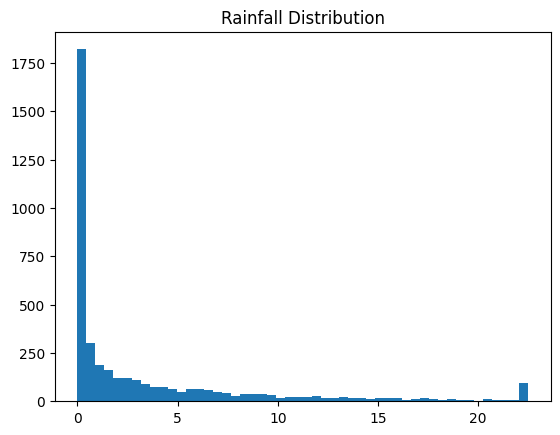

In [36]:
plt.hist(df["PRECTOTCORR"], bins=50)
plt.title("Rainfall Distribution")
plt.show()

# Climate Analysis Report

##  Temperature Trends
The **Monthly Average Temperature** reveals a distinct seasonal cycle:
* **Peak Period:** Temperatures rise sharply in the first quarter, peaking around **April (Month 4)** at approximately **17.9°C**.
* **Cooling Phase:** There is a steady decline through the middle of the year, with a significant "drop-off" starting after June.
* **Annual Low:** The lowest temperatures are recorded in **November (Month 11)**, dipping to nearly **13.8°C**.

##  Rainfall Patterns
The **Monthly Rainfall** data indicates a highly seasonal precipitation regime, likely a monsoon or wet-season pattern:
* **Wet Season:** Rainfall begins to increase in May and surges to a massive peak in **August (Month 8)**, exceeding **3,000 units**.
* **Dry Season:** The end of the year (November–December) and the start of the year (January) are extremely dry, with rainfall levels frequently below **200 units**.
* **Distribution:** The **Rainfall Distribution** shows a "long-tail" distribution. Most days have zero or very low rainfall, while a few extreme events contribute to the bulk of the total precipitation.

##  Strongest Correlations
The correlation analysis provides clear insights into how these variables interact:
* **Wind Speed:** The strongest positive correlation in the dataset is between **WS2M (Wind Speed)** and **WS2M_MAX** (**0.94**). Higher average winds are almost always accompanied by higher peak gusts.
* **Temperature & Humidity:** There is a **strong negative correlation (-0.79)** between **T2M_MAX (Max Temp)** and **RH2M (Relative Humidity)**. This confirms that hotter days in this region tend to be much drier.
* **Temperature Consistency:** **T2M (Average Temp)** correlates strongly with **T2M_MIN (0.72)**, showing that night-time lows have a significant influence on the daily average.

##  Anomalies and Observations
* **Rainfall Extremes:** The distribution data shows a small "bump" at the far right of the scale. This indicates occasional **extreme weather events** (heavy storms) that deviate from the normal daily variation.
* **Wind & Temperature Range:** Observations suggest that days with a wider gap between high and low temperatures (**T2M_RANGE**) often experience higher wind speeds (**WS2M**).
* **Humidity Variance:** While temperature and humidity are negatively correlated, the scatter plots show a high degree of variance, suggesting that local factors or seasonal shifts influence moisture levels independently of raw temperature.

---
**Summary Statement:** *The region experiences a hot, relatively dry spring, followed by a heavy monsoon-style summer that brings cooler temperatures and peak humidity.*
